Linear Regression from Scratch with Gradient Descent Analysis & Real Dataset Experiments

In [1]:
import numpy as np

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


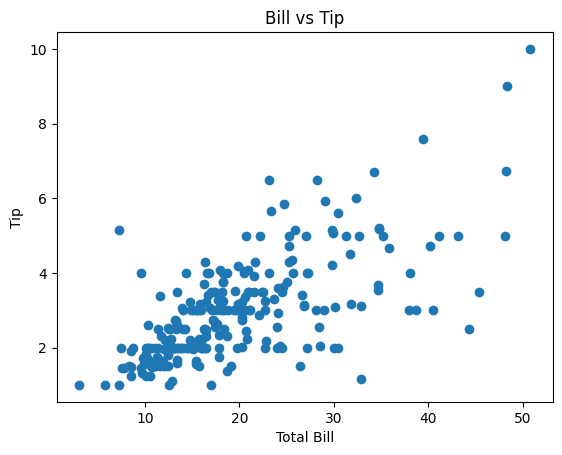

In [5]:
plt.scatter('total_bill', 'tip', data = df)
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Bill vs Tip")
plt.show()

Prepare Data

In [6]:
X = df['total_bill'].values
y = df['tip'].values

In [7]:
X

array([16.99, 10.34, 21.01, 23.68, 24.59, 25.29,  8.77, 26.88, 15.04,
       14.78, 10.27, 35.26, 15.42, 18.43, 14.83, 21.58, 10.33, 16.29,
       16.97, 20.65, 17.92, 20.29, 15.77, 39.42, 19.82, 17.81, 13.37,
       12.69, 21.7 , 19.65,  9.55, 18.35, 15.06, 20.69, 17.78, 24.06,
       16.31, 16.93, 18.69, 31.27, 16.04, 17.46, 13.94,  9.68, 30.4 ,
       18.29, 22.23, 32.4 , 28.55, 18.04, 12.54, 10.29, 34.81,  9.94,
       25.56, 19.49, 38.01, 26.41, 11.24, 48.27, 20.29, 13.81, 11.02,
       18.29, 17.59, 20.08, 16.45,  3.07, 20.23, 15.01, 12.02, 17.07,
       26.86, 25.28, 14.73, 10.51, 17.92, 27.2 , 22.76, 17.29, 19.44,
       16.66, 10.07, 32.68, 15.98, 34.83, 13.03, 18.28, 24.71, 21.16,
       28.97, 22.49,  5.75, 16.32, 22.75, 40.17, 27.28, 12.03, 21.01,
       12.46, 11.35, 15.38, 44.3 , 22.42, 20.92, 15.36, 20.49, 25.21,
       18.24, 14.31, 14.  ,  7.25, 38.07, 23.95, 25.71, 17.31, 29.93,
       10.65, 12.43, 24.08, 11.69, 13.42, 14.26, 15.95, 12.48, 29.8 ,
        8.52, 14.52,

In [8]:
n = len(X)

In [9]:
n

244

Initialize Model

In [10]:
m = 0
b = 0
lr = 0.001
epochs = 1000

losses = []

Train Model

In [11]:
for i in range(epochs):
    
    y_pred = m * X + b
    
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)
    
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    m -= lr * dm
    b -= lr * db

In [12]:
np.min(losses)

np.float64(1.1078238825847508)

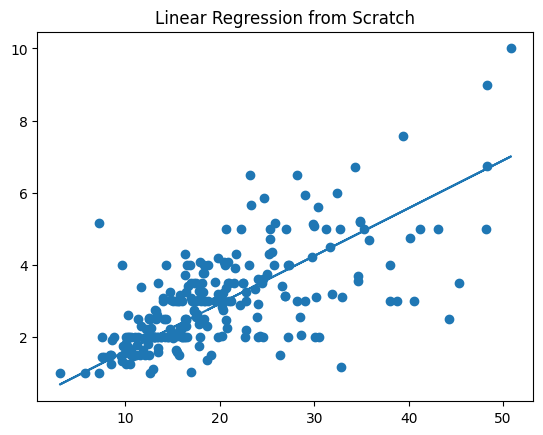

In [13]:
plt.scatter(X, y)
plt.plot(X, m*X + b)
plt.title("Linear Regression from Scratch")
plt.show()

In [14]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


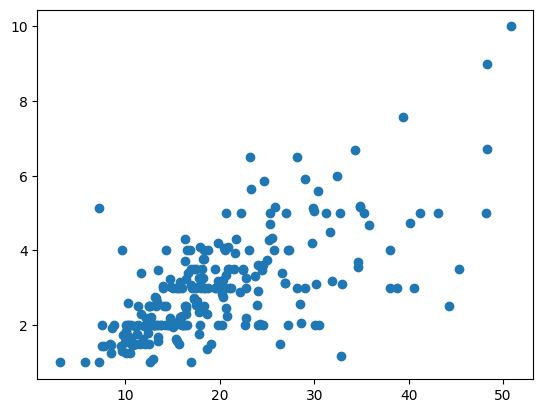

In [15]:
plt.scatter('total_bill', 'tip', data = df)

Epoch : 0
Epoch : 50
Epoch : 100
Epoch : 150
Epoch : 200
Epoch : 250
Epoch : 300
Epoch : 350
Epoch : 400
Epoch : 450
Epoch : 500
Epoch : 550
Epoch : 600
Epoch : 650
Epoch : 700
Epoch : 750
Epoch : 800
Epoch : 850
Epoch : 900
Epoch : 950
0.1422244062881796 0.03615551568437296


<function matplotlib.pyplot.show(close=None, block=None)>

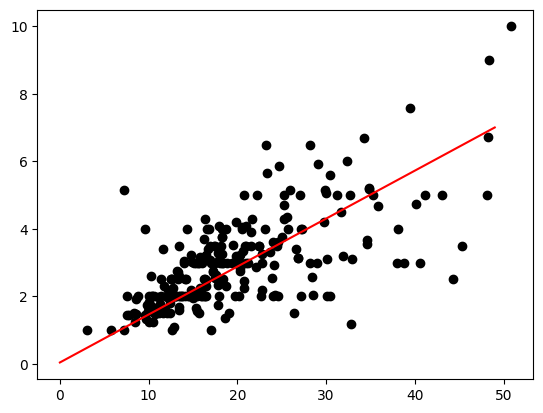

In [16]:
def loss_function(m, b, points):
    total_error = 0
    for i in range (len(points)):
        x = points.iloc[i].total_bill
        y = points.iloc[i].tip
        total_error += (y - (m * x + b))**2
    return total_error / float(len(points))

def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0

    n = len(points)
    for i in range(n):
        x = points.iloc[i].total_bill
        y = points.iloc[i].tip


        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b

m = 0
b = 0
L = 0.0001
epochs = 1000

for i in range(epochs):
    if i % 50 == 0:
        print(f"Epoch : {i}")
    m , b = gradient_descent(m, b, df, L)

print(m, b)

plt.scatter(df.total_bill, df.tip, color= 'black')
plt.plot(list(range(0,50)), [m * x + b for x in range(0,50)], color = 'red')
plt.show

In [17]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [18]:
!pip install scikit-learn

Epoch 0 | Loss: 8.7886
Epoch 100 | Loss: 1.1585
Epoch 200 | Loss: 1.1431
Epoch 300 | Loss: 1.1297
Epoch 400 | Loss: 1.1179
Epoch 500 | Loss: 1.1077
Epoch 600 | Loss: 1.0987
Epoch 700 | Loss: 1.0908
Epoch 800 | Loss: 1.0839
Epoch 900 | Loss: 1.0779
Epoch 1000 | Loss: 1.0727
Epoch 1100 | Loss: 1.0681
Epoch 1200 | Loss: 1.0641
Epoch 1300 | Loss: 1.0605
Epoch 1400 | Loss: 1.0575
Epoch 1500 | Loss: 1.0548
Epoch 1600 | Loss: 1.0524
Epoch 1700 | Loss: 1.0504
Epoch 1800 | Loss: 1.0486
Epoch 1900 | Loss: 1.0470
Epoch 2000 | Loss: 1.0456
Epoch 2100 | Loss: 1.0444
Epoch 2200 | Loss: 1.0434
Epoch 2300 | Loss: 1.0424
Epoch 2400 | Loss: 1.0416
Epoch 2500 | Loss: 1.0409
Epoch 2600 | Loss: 1.0403
Epoch 2700 | Loss: 1.0398
Epoch 2800 | Loss: 1.0393
Epoch 2900 | Loss: 1.0389
Epoch 3000 | Loss: 1.0385
Epoch 3100 | Loss: 1.0382
Epoch 3200 | Loss: 1.0379
Epoch 3300 | Loss: 1.0377
Epoch 3400 | Loss: 1.0375
Epoch 3500 | Loss: 1.0373
Epoch 3600 | Loss: 1.0371
Epoch 3700 | Loss: 1.0370
Epoch 3800 | Loss: 1.036

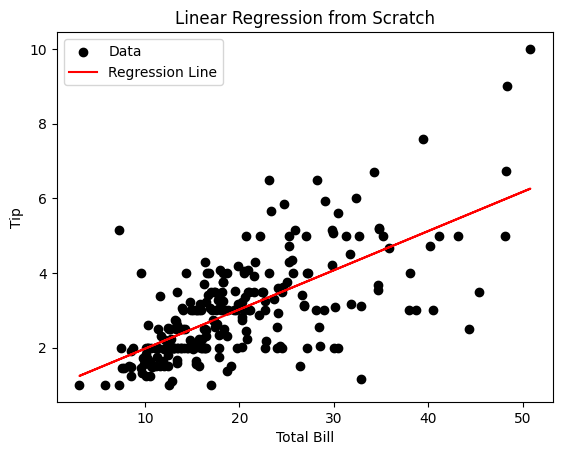

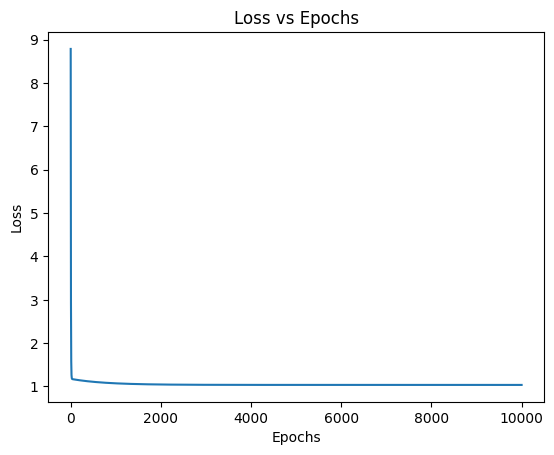


Sklearn Comparison:
Your m: 0.105071781966378
Sklearn m: 0.10502451738435337
Your b: 0.9191462961327869
Sklearn b: 0.9202696135546731


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset("tips")

# LOSS FUNCTION

def loss_function(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points.iloc[i].total_bill
        y = points.iloc[i].tip
        total_error += (y - (m * x + b))**2
    
    return total_error / float(len(points))


# GRADIENT DESCENT

def gradient_descent(m_now, b_now, points, lr):
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x = points.iloc[i].total_bill
        y = points.iloc[i].tip

        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m = m_now - lr * m_gradient
    b = b_now - lr * b_gradient

    return m, b



# TRAINING

m = 0
b = 0
lr = 0.002
epochs = 10000

losses = []

for i in range(epochs):
    m, b = gradient_descent(m, b, df, lr)
    
    loss = loss_function(m, b, df)
    losses.append(loss)

    if i % 100 == 0:
        print(f"Epoch {i} | Loss: {loss:.4f}")

print("\nFinal Parameters:")
print("m:", m)
print("b:", b)


# PLOT REGRESSION LINE

X = df["total_bill"].values
y = df["tip"].values

y_pred = m * X + b

plt.scatter(X, y, color='black', label="Data")
plt.plot(X, y_pred, color='red', label="Regression Line")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Linear Regression from Scratch")
plt.legend()
plt.show()



# LOSS CURVE

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()


# COMPARE WITH SKLEARN

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[['total_bill']], df['tip'])

print("\nSklearn Comparison:")
print("Your m:", m)
print("Sklearn m:", model.coef_[0])

print("Your b:", b)
print("Sklearn b:", model.intercept_)

In [21]:
import sys
!{sys.executable} -m pip install scikit-learn